                 PyVault Benchmark
         1 bytes | Encrypt: 0.00002765s | Decrypt: 0.00001415s
        10 bytes | Encrypt: 0.00001762s | Decrypt: 0.00001589s
       100 bytes | Encrypt: 0.00002039s | Decrypt: 0.00001867s
     1,000 bytes | Encrypt: 0.00003323s | Decrypt: 0.00003133s
    10,000 bytes | Encrypt: 0.00006736s | Decrypt: 0.00005137s
   100,000 bytes | Encrypt: 0.00052471s | Decrypt: 0.00037249s
 1,000,000 bytes | Encrypt: 0.00705277s | Decrypt: 0.00542758s


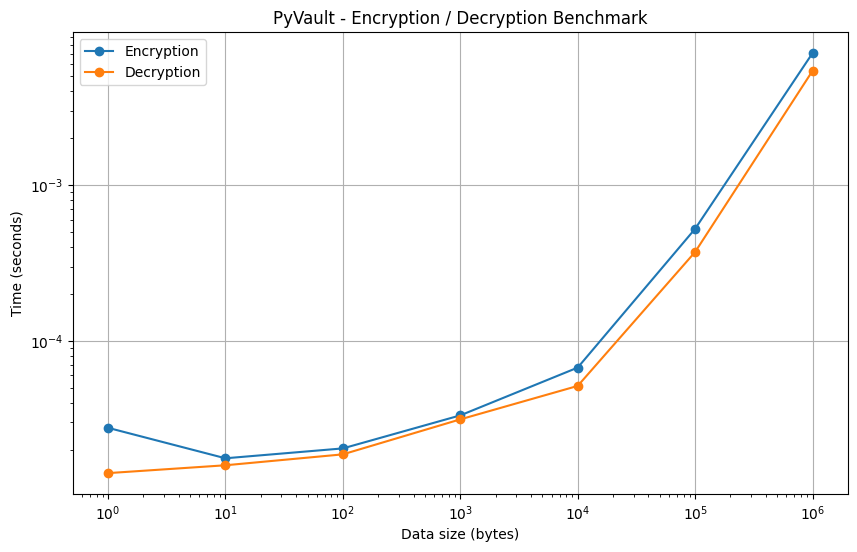

In [1]:
from cryptography.fernet import Fernet
import time
import statistics
import matplotlib.pyplot as plt

fernet = Fernet(Fernet.generate_key())

sizes = [
    1,          # 1 B
    10,         # 10 B
    100,        # 100 B
    1_000,      # 1 KB
    10_000,     # 10 KB
    100_000,    # 100 KB
    1_000_000,  # 1 MB
]

iterations = 100

results = []

print("=" * 65)
print("                 PyVault Benchmark")
print("=" * 65)

for size in sizes:
    data = b"A" * size

    encryption_times = []
    decryption_times = []

    for _ in range(iterations):

        start = time.perf_counter()
        encrypted = fernet.encrypt(data)
        encryption_times.append(time.perf_counter() - start)

        start = time.perf_counter()
        fernet.decrypt(encrypted)
        decryption_times.append(time.perf_counter() - start)

    encrypt_avg = statistics.mean(encryption_times)
    decrypt_avg = statistics.mean(decryption_times)

    results.append({
        "size": size,
        "encrypt": encrypt_avg,
        "decrypt": decrypt_avg
    })

    print(
        f"{size:>10,} bytes | "
        f"Encrypt: {encrypt_avg:.8f}s | "
        f"Decrypt: {decrypt_avg:.8f}s"
    )

print("=" * 65)

x = [r["size"] for r in results]
encrypt = [r["encrypt"] for r in results]
decrypt = [r["decrypt"] for r in results]

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    encrypt,
    marker="o",
    label="Encryption"
)

plt.plot(
    x,
    decrypt,
    marker="o",
    label="Decryption"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Data size (bytes)")
plt.ylabel("Time (seconds)")
plt.title("PyVault - Encryption / Decryption Benchmark")

plt.legend()
plt.grid(True)

plt.show()